In [1]:
# Install all required libraries
import subprocess, sys

packages = [
    'pymupdf',        # PyMuPDF for PDF extraction
    'pytesseract',    # OCR for images
    'easyocr',        # Alternative OCR engine
    'Pillow',         # Image handling
    'pandas',         # Data handling
    'openpyxl',       # Excel file support
    'matplotlib',     # Visualization
    'seaborn',        # Enhanced plots
    'regex',          # Advanced regex
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    print(f'✅ {pkg} installed/verified')

print('\n🎉 All packages ready!')
print('⚠️  Note: For pytesseract OCR, also install Tesseract binary:')
print('   macOS  → brew install tesseract')
print('   Ubuntu → sudo apt-get install tesseract-ocr')


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✅ pymupdf installed/verified



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✅ pytesseract installed/verified



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


...


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✅ matplotlib installed/verified



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✅ seaborn installed/verified
✅ regex installed/verified

🎉 All packages ready!
⚠️  Note: For pytesseract OCR, also install Tesseract binary:
   macOS  → brew install tesseract
   Ubuntu → sudo apt-get install tesseract-ocr



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import fitz                    # PyMuPDF — PDF text extraction
import pytesseract             # Tesseract OCR wrapper
import easyocr                 # EasyOCR — deep-learning OCR
import re                      # Regex for parameter parsing
import os
import warnings
warnings.filterwarnings('ignore')

# ─── Data & Visualization ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from IPython.display import display, HTML

# ─── Configuration ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

DATASET_DIR = './DATASET'

print('✅ All imports successful!')
print(f'📁 Dataset directory: {os.path.abspath(DATASET_DIR)}')
print(f'📦 PyMuPDF version: {fitz.__version__}')

✅ All imports successful!
📁 Dataset directory: /Users/nikhilbhanderi/Desktop/HealthAdvisor-AI/DATASET
📦 PyMuPDF version: 1.27.2.2


In [3]:
def detect_file_type(file_path: str) -> str:
    """
    Detects whether the uploaded file is a PDF or an image.
    Returns: 'pdf', 'image', or 'unknown'
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'❌ File not found: {file_path}')
    
    ext = os.path.splitext(file_path)[1].lower()
    if ext == '.pdf':
        return 'pdf'
    elif ext in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif']:
        return 'image'
    else:
        return 'unknown'


def upload_report(file_path: str) -> dict:
    """
    Main upload handler. Routes to PDF or OCR processor.
    
    Args:
        file_path: Path to the medical report file (PDF or image)
    
    Returns:
        dict with keys: 'text', 'file_type', 'file_name', 'pages'
    """
    print(f'📂 Loading file: {os.path.basename(file_path)}')
    
    file_type = detect_file_type(file_path)
    print(f'📋 Detected type: {file_type.upper()}')
    
    if file_type == 'pdf':
        print('⚡ Routing to PyMuPDF (fast, no OCR needed)...')
        result = extract_text_from_pdf(file_path)
    elif file_type == 'image':
        print('🔍 Routing to OCR processor...')
        result = extract_text_from_image(file_path)
    else:
        raise ValueError(f'Unsupported file type: {file_type}. Use PDF, JPG, or PNG.')
    
    result['file_name'] = os.path.basename(file_path)
    result['file_type'] = file_type
    
    print(f'✅ Extraction complete. Characters extracted: {len(result["text"])}')
    return result


print('✅ Upload Module ready.')
print('   Usage: result = upload_report("path/to/report.pdf")')

✅ Upload Module ready.
   Usage: result = upload_report("path/to/report.pdf")


In [4]:
def extract_text_from_pdf(pdf_path: str) -> dict:
    """
    Extracts text from a PDF medical report using PyMuPDF.
    
    Uses fitz (PyMuPDF) for direct text extraction from digital PDFs.
    No OCR required — fast and highly accurate.
    
    Args:
        pdf_path: Path to the PDF file
    
    Returns:
        dict with 'text' (full extracted text) and 'pages' (count)
    """
    doc = fitz.open(pdf_path)  # Open PDF with PyMuPDF
    
    full_text = ''
    page_texts = []
    
    print(f'📖 PDF has {len(doc)} page(s)')
    
    for page_num, page in enumerate(doc, start=1):
        page_text = page.get_text()   # Extract text from each page
        full_text += page_text + '\n'
        page_texts.append({
            'page': page_num,
            'char_count': len(page_text),
            'preview': page_text[:100].replace('\n', ' ')
        })
        print(f'   Page {page_num}: {len(page_text)} characters')
    
    doc.close()
    
    return {
        'text': full_text,
        'pages': len(page_texts),
        'page_details': page_texts,
        'extraction_method': 'PyMuPDF (Direct — No OCR)'
    }


# ─── Quick PyMuPDF Demo ────────────────────────────────────────────────────────
print('─' * 55)
print('  📄 PDF Processing Module — PyMuPDF')
print('─' * 55)
print('✅ Function ready: extract_text_from_pdf(pdf_path)')
print()
print('Example usage:')
print('  import fitz')
print('  doc = fitz.open("report.pdf")')
print('  text = ""')
print('  for page in doc:')
print('      text += page.get_text()')
print('  print(text)')
print()
print('✔ Advantage: No OCR needed for digital PDFs')
print('✔ High accuracy | ✔ Faster processing')

───────────────────────────────────────────────────────
  📄 PDF Processing Module — PyMuPDF
───────────────────────────────────────────────────────
✅ Function ready: extract_text_from_pdf(pdf_path)

Example usage:
  import fitz
  doc = fitz.open("report.pdf")
  text = ""
  for page in doc:
      text += page.get_text()
  print(text)

✔ Advantage: No OCR needed for digital PDFs
✔ High accuracy | ✔ Faster processing


In [5]:
def extract_text_from_image(image_path: str, use_easyocr: bool = False) -> dict:
    """
    Extracts text from an image-based medical report using OCR.
    
    Primary:  pytesseract (Tesseract OCR)
    Fallback: EasyOCR (deep-learning based)
    
    Args:
        image_path: Path to JPG/PNG image file
        use_easyocr: If True, uses EasyOCR instead of pytesseract
    
    Returns:
        dict with 'text' and extraction metadata
    """
    img = Image.open(image_path)
    print(f'🖼️  Image loaded: {img.size[0]}×{img.size[1]} px, mode={img.mode}')
    
    # ── Pre-process image for better OCR accuracy ────────────────────────────
    img_processed = img.convert('L')            # Convert to grayscale
    
    if use_easyocr:
        print('🤖 Using EasyOCR (deep-learning)...')
        reader = easyocr.Reader(['en'], verbose=False)
        results = reader.readtext(image_path, detail=0)
        text = ' '.join(results)
        method = 'EasyOCR'
    else:
        print('🔤 Using pytesseract (Tesseract OCR)...')
        try:
            # Custom config for medical lab reports (PSM 6 = assume uniform block of text)
            custom_config = r'--oem 3 --psm 6'
            text = pytesseract.image_to_string(img_processed, config=custom_config)
            method = 'pytesseract (Tesseract)'
        except Exception as e:
            print(f'⚠️  pytesseract failed: {e}')
            print('🔄 Falling back to EasyOCR...')
            reader = easyocr.Reader(['en'], verbose=False)
            results = reader.readtext(image_path, detail=0)
            text = ' '.join(results)
            method = 'EasyOCR (fallback)'
    
    return {
        'text': text,
        'pages': 1,
        'extraction_method': method,
        'image_size': f'{img.size[0]}×{img.size[1]}'
    }


print('✅ OCR Module ready.')
print('   Primary:  pytesseract (Tesseract)')
print('   Fallback: EasyOCR')
print('   Usage: result = extract_text_from_image("report.jpg")')

✅ OCR Module ready.
   Primary:  pytesseract (Tesseract)
   Fallback: EasyOCR
   Usage: result = extract_text_from_image("report.jpg")


In [6]:
import re

# ─── Keyword Dictionary (Final Improved) ──────────────────────────────────────
PARAMETER_KEYWORDS = {
    'Hemoglobin': ['hemoglobin', 'haemoglobin', 'hb', 'hgb'],
    'Glucose': ['glucose', 'sugar', 'fbs', 'rbs'],
    'WBC': ['wbc', 'white blood', 'leucocyte', 'total wbc count'],
    'RBC': ['rbc', 'red blood', 'erythrocyte', 'total rbc count'],
    'Platelets': ['platelet', 'plt', 'thrombocyte', 'platelet count'],
    'PCV': ['pcv', 'packed cell volume'],
    'Creatinine': ['creatinine'],
    'Cholesterol': ['cholesterol'],
    'HbA1c': ['hba1c', 'glycated'],
    'Bilirubin': ['bilirubin'],
    'Sodium': ['sodium', 'na+'],
    'Potassium': ['potassium', 'k+']
}

# ─── Safe Keyword Matching ────────────────────────────────────────────────────
def keyword_match(line, keywords):
    for k in keywords:
        pattern = rf'\b{re.escape(k)}\b'
        if re.search(pattern, line):
            return True
    return False


# ─── Smart Value Extraction ───────────────────────────────────────────────────
def extract_value_from_line(line):
    """
    Extract correct value (ignores reference range numbers)
    Example:
    Hemoglobin 12.5 Low 13.0 - 17.0 → returns 12.5
    """
    numbers = re.findall(r"\d+\.?\d*", line)

    if not numbers:
        return None

    # 🔥 IMPORTANT: Take FIRST value (actual result)
    value = float(numbers[0])

    return value


# ─── Core Extraction Function ─────────────────────────────────────────────────
def extract_medical_parameters(text: str) -> dict:
    extracted = {}
    lines = text.split("\n")

    for param, keywords in PARAMETER_KEYWORDS.items():
        for line in lines:
            line_lower = line.lower()

            if keyword_match(line_lower, keywords):

                value = extract_value_from_line(line)

                if value is not None:
                    try:
                        # 🔥 Validation Rules (Prevents wrong extraction)
                        if param == "Hemoglobin" and not (5 <= value <= 25):
                            continue
                        if param == "WBC" and not (1000 <= value <= 20000):
                            continue
                        if param == "Platelets" and not (10000 <= value <= 1000000):
                            continue
                        if param == "RBC" and not (1 <= value <= 10):
                            continue
                        if param == "PCV" and not (10 <= value <= 70):
                            continue

                        extracted[param] = value
                        break

                    except:
                        continue

    return extracted


# ─── Display Function ─────────────────────────────────────────────────────────
def display_extracted_parameters(params: dict):
    if not params:
        print('⚠️  No parameters could be extracted.')
        return
    
    print('\n🧬 Extracted Medical Parameters')
    print('─' * 40)
    
    for param, value in params.items():
        print(f'  {param:<15}: {value}')
    
    print('─' * 40)
    print(f'  Total found: {len(params)} parameter(s)')


# ─── Debug Helper (VERY USEFUL) ───────────────────────────────────────────────
def debug_lines(text):
    """
    Prints lines for debugging extraction issues
    """
    print("\n📄 Debug Lines:")
    print("─" * 40)
    for i, line in enumerate(text.split("\n"), 1):
        print(f"{i:02d}: {line}")


# ─── Status Print ─────────────────────────────────────────────────────────────
print('✅ FINAL Data Extraction Module Ready!')
print(f'   Supports {len(PARAMETER_KEYWORDS)} parameters:')
for p in PARAMETER_KEYWORDS.keys():
    print(f'   • {p}')

✅ FINAL Data Extraction Module Ready!
   Supports 12 parameters:
   • Hemoglobin
   • Glucose
   • WBC
   • RBC
   • Platelets
   • PCV
   • Creatinine
   • Cholesterol
   • HbA1c
   • Bilirubin
   • Sodium
   • Potassium


In [7]:
# ─── Clinical Normal Ranges (WHO / Standard Lab Reference) ────────────────────
NORMAL_RANGES = {
    'Hemoglobin': {
        'male':   {'low': 13.5, 'high': 17.5, 'unit': 'g/dL'},
        'female': {'low': 12.0, 'high': 15.5, 'unit': 'g/dL'},
        'general':{'low': 12.0, 'high': 17.5, 'unit': 'g/dL'},
        'low_msg':  'Low hemoglobin suggests ANEMIA. May cause fatigue, weakness, or breathlessness.',
        'high_msg': 'High hemoglobin may indicate dehydration or polycythemia. Consult a doctor.',
        'normal_msg': 'Hemoglobin is within the healthy range. Good blood oxygen capacity.'
    },
    'Glucose': {
        'general': {'low': 70, 'high': 100, 'unit': 'mg/dL'},
        'low_msg':  'Low blood sugar (Hypoglycemia). Symptoms: dizziness, sweating. Eat something sweet immediately.',
        'high_msg': 'High blood sugar. Values > 126 mg/dL suggest DIABETES. Please consult a doctor.',
        'normal_msg': 'Fasting blood glucose is normal. No signs of diabetes.'
    },
    'WBC': {
        'general': {'low': 4.5, 'high': 11.0, 'unit': 'K/μL (×10³)'},
        'low_msg':  'Low WBC count (Leukopenia). Immune system may be weakened. Risk of infections is higher.',
        'high_msg': 'High WBC count (Leukocytosis). May indicate infection, inflammation, or stress response.',
        'normal_msg': 'White blood cell count is normal. Immune system appears healthy.'
    },
    'RBC': {
        'male':   {'low': 4.7, 'high': 6.1, 'unit': 'M/μL'},
        'female': {'low': 4.2, 'high': 5.4, 'unit': 'M/μL'},
        'general':{'low': 4.2, 'high': 6.1, 'unit': 'M/μL'},
        'low_msg':  'Low RBC count may indicate anemia or bone marrow issues.',
        'high_msg': 'High RBC count (Polycythemia). May be related to dehydration or lung disease.',
        'normal_msg': 'Red blood cell count is normal.'
    },
    'Platelets': {
        'general': {'low': 150, 'high': 400, 'unit': 'K/μL (×10³)'},
        'low_msg':  'Low platelet count (Thrombocytopenia). Risk of excessive bleeding. Seek medical advice.',
        'high_msg': 'High platelet count (Thrombocytosis). Risk of blood clots. Consult a physician.',
        'normal_msg': 'Platelet count is within normal limits. Clotting function appears healthy.'
    },
    'Creatinine': {
        'male':   {'low': 0.74, 'high': 1.35, 'unit': 'mg/dL'},
        'female': {'low': 0.59, 'high': 1.04, 'unit': 'mg/dL'},
        'general':{'low': 0.6,  'high': 1.35, 'unit': 'mg/dL'},
        'low_msg':  'Low creatinine may indicate low muscle mass or liver disease.',
        'high_msg': 'High creatinine suggests possible KIDNEY dysfunction. Consult a nephrologist.',
        'normal_msg': 'Creatinine level is normal. Kidneys appear to be functioning well.'
    },
    'Cholesterol': {
        'general': {'low': 0, 'high': 200, 'unit': 'mg/dL'},
        'low_msg':  'Very low cholesterol. May affect hormone production. Consult a doctor.',
        'high_msg': 'High cholesterol (Hypercholesterolemia). Risk of heart disease. Diet and exercise advised.',
        'normal_msg': 'Total cholesterol is within desirable range. Good cardiovascular health indicator.'
    },
    'HbA1c': {
        'general': {'low': 0, 'high': 5.7, 'unit': '%'},
        'low_msg':  'HbA1c is very low. Hypoglycaemia risk. Consult a doctor.',
        'high_msg': 'Elevated HbA1c: 5.7-6.4% = PREDIABETES; ≥6.5% = DIABETES. See an endocrinologist.',
        'normal_msg': 'HbA1c is normal (< 5.7%). No diabetes detected over past 3 months.'
    },
    'Bilirubin': {
        'general': {'low': 0.1, 'high': 1.2, 'unit': 'mg/dL'},
        'low_msg':  'Bilirubin is very low — generally not a concern.',
        'high_msg': 'High bilirubin (Hyperbilirubinemia). May indicate liver disease or bile duct blockage.',
        'normal_msg': 'Bilirubin level is normal. Liver and bile duct function appears healthy.'
    },
    'Sodium': {
        'general': {'low': 136, 'high': 145, 'unit': 'mEq/L'},
        'low_msg':  'Low sodium (Hyponatremia). Symptoms: nausea, headache. May need IV therapy.',
        'high_msg': 'High sodium (Hypernatremia). Usually caused by dehydration. Increase water intake.',
        'normal_msg': 'Sodium levels are normal. Good electrolyte balance.'
    },
    'Potassium': {
        'general': {'low': 3.5, 'high': 5.0, 'unit': 'mEq/L'},
        'low_msg':  'Low potassium (Hypokalemia). Risk of muscle weakness, cramps, and heart arrhythmias.',
        'high_msg': 'High potassium (Hyperkalemia). Can affect heart rhythm. Seek immediate medical attention.',
        'normal_msg': 'Potassium levels are normal. Good cardiac and muscular function support.'
    },
}


def analyze_parameter(param_name: str, value: float, gender: str = 'general') -> dict:
    """
    Rule-based expert system analysis for a single medical parameter.
    
    Args:
        param_name: Name of the parameter (e.g., 'Hemoglobin')
        value: Measured value
        gender: 'male', 'female', or 'general'
    
    Returns:
        dict with 'status', 'message', 'low', 'high', 'unit'
    """
    if param_name not in NORMAL_RANGES:
        return {
            'status': 'Unknown',
            'message': 'Parameter not in reference database.',
            'value': value, 'low': None, 'high': None, 'unit': ''
        }
    
    ref = NORMAL_RANGES[param_name]
    
    # Pick gender-specific or general range
    if gender in ref:
        ranges = ref[gender]
    else:
        ranges = ref['general']
    
    low_val  = ranges['low']
    high_val = ranges['high']
    unit     = ranges['unit']
    
    if value < low_val:
        status  = '🔴 LOW'
        message = ref['low_msg']
    elif value > high_val:
        status  = '🟡 HIGH'
        message = ref['high_msg']
    else:
        status  = '🟢 NORMAL'
        message = ref['normal_msg']
    
    return {
        'status':  status,
        'message': message,
        'value':   value,
        'low':     low_val,
        'high':    high_val,
        'unit':    unit
    }


def analyze_all_parameters(params: dict, gender: str = 'general') -> list:
    """
    Runs analysis on all extracted parameters.
    
    Returns list of result dicts with full analysis.
    """
    results = []
    for param, value in params.items():
        analysis = analyze_parameter(param, value, gender)
        analysis['parameter'] = param
        results.append(analysis)
    return results


print('✅ Analysis Module ready.')
print(f'   Expert system covers {len(NORMAL_RANGES)} parameters with clinical ranges')
print('   Supports gender-specific ranges for: Hemoglobin, RBC, Creatinine')

✅ Analysis Module ready.
   Expert system covers 11 parameters with clinical ranges
   Supports gender-specific ranges for: Hemoglobin, RBC, Creatinine


In [8]:
def display_results(results: list, patient_name: str = 'Patient', report_info: dict = None):
    """
    Displays analysis results in a clear, formatted report.
    """
    print('\n' + '═' * 65)
    print(f'  🏥 MEDICAL REPORT ANALYSIS — {patient_name.upper()}')
    if report_info:
        print(f'  📄 File: {report_info.get("file_name", "N/A")} '
              f'| Method: {report_info.get("extraction_method", "N/A")}')
    print('═' * 65)
    
    if not results:
        print('⚠️  No medical parameters could be analyzed.')
        return
    
    normal_count = sum(1 for r in results if 'NORMAL' in r['status'])
    high_count   = sum(1 for r in results if 'HIGH'   in r['status'])
    low_count    = sum(1 for r in results if 'LOW'    in r['status'])
    
    for r in results:
        print(f"\n  📌 {r['parameter']:<15} → {r['status']}")
        print(f"     Value  : {r['value']} {r['unit']}")
        print(f"     Range  : {r['low']} – {r['high']} {r['unit']}")
        print(f"     Advice : {r['message']}")
    
    print('\n' + '─' * 65)
    print(f'  📊 SUMMARY: {len(results)} parameters analyzed')
    print(f'     🟢 Normal: {normal_count}  |  🟡 High: {high_count}  |  🔴 Low: {low_count}')
    
    # Overall health advisory
    print('\n  💬 HEALTH ADVISORY:')
    if normal_count == len(results):
        print('  ✅ All parameters are within normal ranges. Continue healthy habits!')
    elif high_count > 0 or low_count > 0:
        print('  ⚠️  Some parameters are outside normal range.')
        print('  👨‍⚕️ Please consult a qualified healthcare provider for guidance.')
        print('  🏥 Do not self-medicate based on these results.')
    print('═' * 65)


def plot_results(results: list, patient_name: str = 'Patient'):
    """
    Generates a visual bar chart comparing measured values against normal ranges.
    """
    if not results:
        print('No results to plot.')
        return
    
    # Filter only results with numeric ranges
    plottable = [r for r in results if r['low'] is not None and r['low'] >= 0]
    if not plottable:
        print('No plottable results.')
        return
    
    fig, axes = plt.subplots(1, len(plottable), figsize=(4 * len(plottable), 5))
    if len(plottable) == 1:
        axes = [axes]
    
    color_map = {'🟢 NORMAL': '#2ecc71', '🟡 HIGH': '#e67e22', '🔴 LOW': '#e74c3c'}
    
    for ax, r in zip(axes, plottable):
        color = color_map.get(r['status'], '#3498db')
        
        # Plot normal range zone
        ax.axhspan(r['low'], r['high'], alpha=0.15, color='#2ecc71', label='Normal Range')
        
        # Plot measured value bar
        ax.bar(r['parameter'], r['value'], color=color, alpha=0.85, width=0.5,
               edgecolor='white', linewidth=1.5)
        
        # Reference lines
        ax.axhline(r['low'],  color='#27ae60', linestyle='--', linewidth=1, alpha=0.7)
        ax.axhline(r['high'], color='#e74c3c', linestyle='--', linewidth=1, alpha=0.7)
        
        ax.set_title(f"{r['parameter']}\n{r['status']}", fontsize=11, fontweight='bold')
        ax.set_ylabel(r['unit'], fontsize=9)
        ax.set_xticks([])
        
        # Annotate value
        ax.text(0, r['value'] + 0.02 * r['value'], f"{r['value']}",
                ha='center', fontweight='bold', fontsize=12, color=color)
    
    plt.suptitle(f'🏥 Medical Report — {patient_name}', fontsize=14,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('analysis_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📊 Chart saved as analysis_results.png')


print('✅ Result Display Module ready.')

✅ Result Display Module ready.


In [9]:
print('═' * 55)
print('  📊 Loading Medical Datasets from ./DATASET/')
print('═' * 55)

# ─── Load Datasets ────────────────────────────────────────────────────────────
datasets = {}

# 1. Diabetes Prediction Dataset
try:
    df_diabetes = pd.read_csv(f'{DATASET_DIR}/diabetes_prediction_dataset.csv')
    datasets['diabetes'] = df_diabetes
    print(f'✅ diabetes_prediction_dataset.csv — {df_diabetes.shape[0]:,} rows × {df_diabetes.shape[1]} cols')
except Exception as e:
    print(f'❌ Could not load diabetes dataset: {e}')
    df_diabetes = None

# 2. Health Markers Dataset
try:
    df_health = pd.read_csv(f'{DATASET_DIR}/health_markers_dataset.csv')
    datasets['health_markers'] = df_health
    print(f'✅ health_markers_dataset.csv — {df_health.shape[0]:,} rows × {df_health.shape[1]} cols')
except Exception as e:
    print(f'❌ Could not load health markers dataset: {e}')
    df_health = None

# 3. CBC Information (Excel)
try:
    df_cbc = pd.read_excel(f'{DATASET_DIR}/cbc information.xlsx')
    datasets['cbc'] = df_cbc
    print(f'✅ cbc information.xlsx — {df_cbc.shape[0]:,} rows × {df_cbc.shape[1]} cols')
except Exception as e:
    print(f'❌ Could not load CBC Excel: {e}')
    df_cbc = None

# 4. Filtered Dataset (Excel)
try:
    df_filtered = pd.read_excel(f'{DATASET_DIR}/filtered_dataset.xlsx')
    datasets['filtered'] = df_filtered
    print(f'✅ filtered_dataset.xlsx — {df_filtered.shape[0]:,} rows × {df_filtered.shape[1]} cols')
except Exception as e:
    print(f'❌ Could not load filtered dataset: {e}')
    df_filtered = None

print(f'\n📁 Loaded {len(datasets)} dataset(s) successfully.')

═══════════════════════════════════════════════════════
  📊 Loading Medical Datasets from ./DATASET/
═══════════════════════════════════════════════════════
✅ diabetes_prediction_dataset.csv — 100,000 rows × 9 cols
✅ health_markers_dataset.csv — 25,000 rows × 10 cols
✅ cbc information.xlsx — 500 rows × 21 cols
✅ filtered_dataset.xlsx — 4,598 rows × 14 cols

📁 Loaded 4 dataset(s) successfully.



📋 Diabetes Prediction Dataset — Head:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



📋 Basic Statistics:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


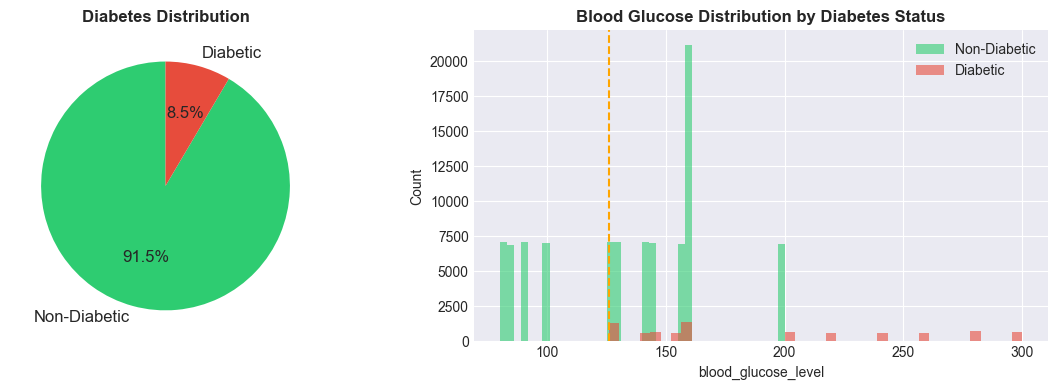


📋 Health Markers Dataset — Head:


,Blood_glucose,HbA1C,Systolic_BP,Diastolic_BP,LDL,HDL,Triglycerides,Haemoglobin,MCV,Condition
0,107.38,4.93,109.25,74.10,129.20,52.11,68.84,10.17,61.54,Anemia
1,108.65,5.43,92.61,62.02,51.18,44.06,78.82,12.29,91.04,Fit
2,103.95,6.08,122.95,63.01,107.72,52.08,139.58,15.93,81.75,Fit
3,87.33,4.79,91.16,75.81,109.39,46.83,108.29,15.18,85.51,Fit
4,114.42,4.10,122.86,76.11,123.89,52.92,123.22,15.33,92.30,Fit



📋 CBC Information — Head:


,ID,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,...,MCV,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR
0,1,10.0,43.2,6.7,50.1,4.3,0.7,5.0,2.77,7.3,...,87.7,26.3,30.1,35.3,11.4,189.0,9.2,12.5,0.17,22.3
1,2,10.0,42.4,5.3,52.3,4.2,0.5,5.3,2.84,7.3,...,88.2,25.7,20.2,35.3,11.4,180.0,8.9,12.5,0.16,19.5
2,3,7.2,30.7,8.6,60.7,2.2,0.6,4.4,3.97,9.0,...,77.0,22.6,29.5,37.2,13.7,148.0,10.1,14.3,0.14,30.5
3,4,6.0,30.2,6.3,63.5,1.8,0.4,3.8,4.22,3.8,...,77.9,23.2,29.8,46.5,17.0,143.0,8.6,11.3,0.12,16.4
4,5,4.2,39.1,7.2,53.7,1.6,0.3,2.3,3.93,0.4,...,80.6,23.9,29.7,42.7,15.1,236.0,19.5,12.8,0.22,24.8


In [10]:
# ─── Exploratory Data Analysis ────────────────────────────────────────────────
if df_diabetes is not None:
    print('\n📋 Diabetes Prediction Dataset — Head:')
    display(df_diabetes.head())
    print('\n📋 Basic Statistics:')
    display(df_diabetes.describe())
    
    # Diabetic vs Non-Diabetic Distribution
    if 'diabetes' in df_diabetes.columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Pie chart
        counts = df_diabetes['diabetes'].value_counts()
        labels = ['Non-Diabetic', 'Diabetic']
        colors = ['#2ecc71', '#e74c3c']
        axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
                    startangle=90, textprops={'fontsize': 12})
        axes[0].set_title('Diabetes Distribution', fontweight='bold')
        
        # Blood Glucose Distribution
        glucose_col = None
        for col in df_diabetes.columns:
            if 'glucose' in col.lower() or 'blood_glucose' in col.lower():
                glucose_col = col
                break
        
        if glucose_col:
            for label, group in df_diabetes.groupby('diabetes'):
                axes[1].hist(group[glucose_col].dropna(), bins=40, alpha=0.6,
                             label='Diabetic' if label == 1 else 'Non-Diabetic',
                             color='#e74c3c' if label == 1 else '#2ecc71')
            axes[1].set_xlabel(glucose_col)
            axes[1].set_ylabel('Count')
            axes[1].set_title('Blood Glucose Distribution by Diabetes Status', fontweight='bold')
            axes[1].legend()
            axes[1].axvline(x=126, color='orange', linestyle='--', label='Diabetes threshold (126 mg/dL)')
        
        plt.tight_layout()
        plt.show()
    
if df_health is not None:
    print('\n📋 Health Markers Dataset — Head:')
    display(df_health.head())

if df_cbc is not None:
    print('\n📋 CBC Information — Head:')
    display(df_cbc.head())

In [11]:
def run_analysis(file_path: str, patient_name: str = 'Patient',
                 gender: str = 'general', plot: bool = True) -> dict:
    """
    🔄 FULL PIPELINE: Upload → Extract → Parse → Analyze → Display
    
    Args:
        file_path:    Path to medical report (PDF or Image)
        patient_name: Name of the patient for report header
        gender:       'male', 'female', or 'general'
        plot:         Whether to generate bar charts
    
    Returns:
        dict with extracted text, parameters, and analysis results
    """
    print('\n' + '═' * 65)
    print('  🚀 Starting Medical Report Analysis Pipeline')
    print('═' * 65)
    
    # ── Step 1: Upload & Detect ───────────────────────────────────────────────
    print('\n[Step 1/4] 📥 Uploading and detecting file type...')
    report_info = upload_report(file_path)
    
    # ── Step 2: Extract Text ──────────────────────────────────────────────────
    print('\n[Step 2/4] 📝 Text extracted successfully.')
    raw_text = report_info['text']
    print(f'   Preview: {raw_text[:200].replace(chr(10), " ")}...')
    
    # ── Step 3: Parse Parameters ─────────────────────────────────────────────
    print('\n[Step 3/4] 🧬 Extracting medical parameters...')
    params = extract_medical_parameters(raw_text)
    display_extracted_parameters(params)
    
    # ── Step 4: Analyze ───────────────────────────────────────────────────────
    print('\n[Step 4/4] ⚕️  Applying rule-based expert analysis...')
    results = analyze_all_parameters(params, gender=gender)
    
    # ── Output ────────────────────────────────────────────────────────────────
    display_results(results, patient_name=patient_name, report_info=report_info)
    
    if plot and results:
        plot_results(results, patient_name=patient_name)
    
    return {
        'report_info': report_info,
        'raw_text':    raw_text,
        'parameters':  params,
        'results':     results
    }


print('✅ Full Pipeline ready.')
print()
print('Usage:')
print('  # For a PDF report:')
print('  output = run_analysis("patient_report.pdf", patient_name="John Doe", gender="male")')
print()
print('  # For an image report:')
print('  output = run_analysis("lab_report.jpg", patient_name="Jane Doe", gender="female")')

✅ Full Pipeline ready.

Usage:
  # For a PDF report:
  output = run_analysis("patient_report.pdf", patient_name="John Doe", gender="male")

  # For an image report:
  output = run_analysis("lab_report.jpg", patient_name="Jane Doe", gender="female")


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# 🤖 AI EXPLANATION MODULE
# Implements the structured prompt for generating human-readable medical summaries
# ═══════════════════════════════════════════════════════════════════════════

REPORT_TYPE_HINTS = {
    frozenset(['Hemoglobin', 'WBC', 'RBC', 'Platelets']): 'Complete Blood Count (CBC)',
    frozenset(['Glucose', 'HbA1c']): 'Diabetes / Blood Sugar Panel',
    frozenset(['Creatinine']): 'Kidney Function Test (KFT)',
    frozenset(['Cholesterol', 'Bilirubin']): 'Liver & Lipid Panel',
    frozenset(['Sodium', 'Potassium']): 'Electrolyte Panel',
}

STATUS_EMOJI = {
    'LOW':     '🔴 LOW',
    'NORMAL':  '🟢 NORMAL',
    'HIGH':    '🟡 HIGH',
    'Unknown': '⬜ UNKNOWN',
}

ADVICE_LIBRARY = {
    'Hemoglobin': {
        'LOW':  'Low hemoglobin (anemia) can make you feel tired and weak. Eat iron-rich foods like spinach, lentils, and meat. Rest well.',
        'HIGH': 'High hemoglobin may mean your blood is thicker than normal. Drink plenty of water and avoid smoking.'
    },
    'Glucose': {
        'LOW':  'Your blood sugar is too low. Eat or drink something sugary right away. Avoid skipping meals.',
        'HIGH': 'Your blood sugar is high, which may be a sign of diabetes. Reduce sugary foods, exercise regularly, and monitor your sugar levels.'
    },
    'WBC': {
        'LOW':  'Your white blood cell count is low, which means your body may struggle to fight infections. Avoid crowded places and maintain hygiene.',
        'HIGH': 'A high white blood cell count usually means your body is fighting an infection or inflammation. Rest and stay hydrated.'
    },
    'RBC': {
        'LOW':  'You have fewer red blood cells than normal. This can cause fatigue and breathlessness. Eat nutritious food and consult your doctor.',
        'HIGH': 'Too many red blood cells can thicken your blood. Drink more water and get checked by a doctor.'
    },
    'Platelets': {
        'LOW':  'Low platelets increase the risk of unusual bleeding or bruising. Avoid injury and see a doctor promptly.',
        'HIGH': 'High platelets can increase the risk of blood clots. Your doctor may need to monitor this closely.'
    },
    'Creatinine': {
        'LOW':  'Very low creatinine may relate to low muscle mass. Generally not alarming but worth mentioning to your doctor.',
        'HIGH': 'High creatinine may suggest your kidneys are under stress. Drink enough water and reduce high-protein foods until you see a doctor.'
    },
    'Cholesterol': {
        'HIGH': 'High cholesterol increases heart disease risk. Eat less fried or fatty food. Walk for at least 30 minutes daily.'
    },
    'HbA1c': {
        'HIGH': 'Elevated HbA1c shows your blood sugar has been high over the past 3 months. This may indicate diabetes or pre-diabetes. Lifestyle changes are important.'
    },
    'Bilirubin': {
        'HIGH': 'High bilirubin can cause yellowing of skin or eyes (jaundice). Avoid alcohol and see a doctor.'
    },
    'Sodium': {
        'LOW':  'Low sodium can cause headaches, nausea, or confusion. Increase salt intake slightly and consult a doctor.',
        'HIGH': 'High sodium means dehydration risk. Drink more water and reduce salty foods.'
    },
    'Potassium': {
        'LOW':  'Low potassium can cause weakness or muscle cramps. Eat bananas, potatoes, and leafy greens.',
        'HIGH': 'High potassium can affect heart rhythm. Avoid high-potassium foods and seek medical care.'
    },
}


def _detect_report_type(results: list) -> str:
    """Detects report type based on present parameters."""
    param_set = set(r['parameter'] for r in results)
    for hint_set, report_name in REPORT_TYPE_HINTS.items():
        if hint_set.issubset(param_set):
            return report_name
    if len(param_set) >= 4:
        return 'Comprehensive Medical Panel'
    return 'Medical Lab Report'


def _get_status_word(status_str: str) -> str:
    """Extracts clean status word from emoji status string."""
    for key in ['LOW', 'HIGH', 'NORMAL', 'Unknown']:
        if key in status_str.upper():
            return key
    return 'Unknown'


def generate_explanation(results: list, patient_name: str = 'Patient',
                         gemini_api_key: str = None) -> str:
    """
    🤖 AI EXPLANATION GENERATOR
    ─────────────────────────────────────────────────────────────────────────
    Implements the structured medical AI prompt to generate a clear,
    user-friendly explanation of medical report results.

    Prompt Logic:
      1. Identify report type (CBC, Diabetes Panel, etc.)
      2. For each parameter: name, value, status, simple interpretation
      3. General health advice for abnormal values
      4. No specific medicines or prescriptions
      5. Concise, easy-to-understand language
      6. Final recommendation to consult a doctor

    Args:
        results:        Output from analyze_all_parameters()
        patient_name:   Name of the patient
        gemini_api_key: Optional Google Gemini API key for AI generation

    Returns:
        str — human-readable medical report explanation
    """
    if gemini_api_key:
        return _generate_with_gemini(results, patient_name, gemini_api_key)
    else:
        return _generate_rule_based(results, patient_name)


def _generate_rule_based(results: list, patient_name: str) -> str:
    """Offline rule-based explanation generator following the structured prompt."""

    report_type   = _detect_report_type(results)
    abnormal      = [r for r in results if 'NORMAL' not in r['status'] and 'Unknown' not in r['status']]
    normal_params = [r for r in results if 'NORMAL' in r['status']]

    lines = []

    # ── Header ────────────────────────────────────────────────────────────────
    lines.append('═' * 65)
    lines.append(f'  🏥 HEALTH REPORT EXPLANATION — {patient_name.upper()}')
    lines.append(f'  📋 Report Type: {report_type}')
    lines.append('═' * 65)
    lines.append('')
    lines.append('Dear ' + patient_name + ',')
    lines.append('')
    lines.append(f'Below is a simple explanation of your {report_type} results.')
    lines.append('This is meant to help you understand your health status in plain language.')
    lines.append('')

    # ── Per Parameter Explanation ─────────────────────────────────────────────
    lines.append('─' * 65)
    lines.append('📌 PARAMETER-BY-PARAMETER EXPLANATION')
    lines.append('─' * 65)

    for r in results:
        status_word = _get_status_word(r['status'])
        emoji_map = {'NORMAL': '🟢', 'HIGH': '🟡', 'LOW': '🔴', 'Unknown': '⬜'}
        emoji = emoji_map.get(status_word, '⬜')

        lines.append('')
        lines.append(f'{emoji} {r["parameter"]}')
        lines.append(f'   Measured Value : {r["value"]} {r["unit"]}')
        lines.append(f'   Normal Range   : {r["low"]} – {r["high"]} {r["unit"]}')
        lines.append(f'   Status         : {status_word}')

        # Simple interpretation
        if status_word == 'NORMAL':
            lines.append(f'   Meaning        : ✅ Your {r["parameter"]} is within the healthy range. No concern here.')
        elif status_word in ADVICE_LIBRARY.get(r['parameter'], {}):
            advice = ADVICE_LIBRARY[r['parameter']][status_word]
            lines.append(f'   Meaning        : ⚠️  {advice}')
        else:
            lines.append(f'   Meaning        : This value is {status_word.lower()} — discuss with your doctor.')

    # ── General Health Advice ─────────────────────────────────────────────────
    if abnormal:
        lines.append('')
        lines.append('─' * 65)
        lines.append('💡 GENERAL HEALTH ADVICE (based on your results)')
        lines.append('─' * 65)
        lines.append('')
        lines.append('Based on the abnormal values found in your report:')
        lines.append('')

        seen_advice = set()
        for r in abnormal:
            status_word = _get_status_word(r['status'])
            param_advice = ADVICE_LIBRARY.get(r['parameter'], {}).get(status_word)
            if param_advice and param_advice not in seen_advice:
                lines.append(f'  • {param_advice}')
                seen_advice.add(param_advice)

        lines.append('')
        lines.append('General tips for everyone:')
        lines.append('  • Drink at least 8 glasses of water per day')
        lines.append('  • Eat a balanced diet with vegetables, fruits, and whole grains')
        lines.append('  • Get at least 30 minutes of light physical activity daily')
        lines.append('  • Avoid smoking and excessive alcohol')
        lines.append('  • Get adequate sleep (7–8 hours per night)')
    else:
        lines.append('')
        lines.append('─' * 65)
        lines.append('💡 HEALTH ADVICE')
        lines.append('─' * 65)
        lines.append('')
        lines.append('✅ Great news! All your tested parameters are within normal limits.')
        lines.append('   Keep up your healthy lifestyle:')
        lines.append('  • Continue eating a balanced diet')
        lines.append('  • Stay physically active')
        lines.append('  • Get regular health check-ups')

    # ── Disclaimer & Doctor Recommendation ────────────────────────────────────
    lines.append('')
    lines.append('═' * 65)
    lines.append('👨‍⚕️  IMPORTANT — CONSULT YOUR DOCTOR')
    lines.append('═' * 65)
    lines.append('')
    lines.append('This explanation is generated by an AI system for informational')
    lines.append('purposes only. It does NOT replace professional medical advice.')
    lines.append('')
    lines.append('⚠️  Please consult a qualified doctor or healthcare provider to:')
    lines.append('   • Confirm the diagnosis')
    lines.append('   • Understand your results in context of your full health history')
    lines.append('   • Get appropriate treatment if needed')
    lines.append('')
    lines.append('❌ Do NOT self-medicate based on these results.')
    lines.append('═' * 65)

    return '
'.join(lines)


def _generate_with_gemini(results: list, patient_name: str, api_key: str) -> str:
    """
    Uses Google Gemini API to generate the explanation.
    Requires: pip install google-generativeai
    """
    try:
        import google.generativeai as genai
        genai.configure(api_key=api_key)
        model = genai.GenerativeModel('gemini-pro')

        # Build structured input from results
        params_text = '
'.join([
            f'- {r["parameter"]}: {r["value"]} {r["unit"]} → Status: {_get_status_word(r["status"])} '
            f'(Normal: {r["low"]}–{r["high"]})'
            for r in results
        ])

        prompt = f"""You are an AI-based medical assistant.

Analyze the given medical report results and generate a clear, simple, and user-friendly explanation suitable for a non-technical person.

Instructions:
1. Identify the type of report (e.g., Complete Blood Count - CBC).
2. For each parameter, mention:
   - Parameter name
   - Measured value
   - Status (Low / Normal / High)
   - Simple interpretation of the result
3. Provide general health advice based on abnormal values.
4. Do not suggest any specific medicines or prescriptions.
5. Keep the explanation concise and easy to understand.
6. Always include a final recommendation to consult a qualified doctor.

Patient Name: {patient_name}

Input (Structured Medical Parameters):
{params_text}

Output:
A natural language summary explaining the report and basic health advice."""

        response = model.generate_content(prompt)
        return response.text

    except ImportError:
        print('⚠️  google-generativeai not installed. Run: pip install google-generativeai')
        print('🔄 Falling back to rule-based explanation...')
        return _generate_rule_based(results, patient_name)
    except Exception as e:
        print(f'⚠️  Gemini API error: {e}')
        print('🔄 Falling back to rule-based explanation...')
        return _generate_rule_based(results, patient_name)


print('✅ AI Explanation Module ready.')
print()
print('Usage (offline, no API key):')
print('  explanation = generate_explanation(results, patient_name="Ramesh Kumar")')
print('  print(explanation)')
print()
print('Usage (with Google Gemini AI):')
print('  explanation = generate_explanation(results, patient_name="Ramesh Kumar",')
print('                                     gemini_api_key="YOUR_GEMINI_KEY")')


SyntaxError: unterminated string literal (detected at line 215) (3183820943.py, line 215)

In [ ]:
# ─── Run AI Explanation on Sample Report ─────────────────────────────────────
# Uses the same sample_results from Cell 11 (Demo cell)
# Re-run Cell 11 first if sample_results is not defined

try:
    explanation = generate_explanation(
        results      = sample_results,
        patient_name = 'Ramesh Kumar',
        # gemini_api_key = 'YOUR_GEMINI_API_KEY'   # ← Uncomment & add key for AI mode
    )
    print(explanation)

except NameError:
    print('⚠️  sample_results not found. Please run Cell 11 (Demo) first.')
    print('   Then re-run this cell.')


In [ ]:
# ─── Sample Medical Report Text ───────────────────────────────────────────────
# Simulates text extracted from a real CBC + Metabolic panel report

SAMPLE_REPORT_TEXT = """
PATHOLOGY LABORATORY — DIAGNOSTIC REPORT
=========================================
Patient Name : Ramesh Kumar
Age          : 45 years
Gender       : Male
Date         : 21/04/2026
Ref. Doctor  : Dr. A. Sharma

COMPLETE BLOOD COUNT (CBC)
--------------------------
Hemoglobin       : 10.2 g/dL       (Normal: 13.5 - 17.5)
RBC Count        : 3.9 M/uL        (Normal: 4.7 - 6.1)
WBC Count        : 12.5 K/uL       (Normal: 4.5 - 11.0)
Platelets        : 180 K/uL        (Normal: 150 - 400)

BLOOD CHEMISTRY
---------------
Glucose (Fasting): 138 mg/dL       (Normal: 70 - 100)
HbA1c            : 7.2 %           (Normal: < 5.7)
Creatinine       : 1.6 mg/dL       (Normal: 0.74 - 1.35)
Total Cholesterol: 230 mg/dL       (Normal: < 200)
Total Bilirubin  : 0.8 mg/dL       (Normal: 0.1 - 1.2)
Sodium (Na+)     : 140 mEq/L       (Normal: 136 - 145)
Potassium (K+)   : 3.2 mEq/L       (Normal: 3.5 - 5.0)

=========================================
*** For clinical use only. Consult a physician. ***
"""

print('━' * 65)
print('  🧪 DEMO — Running Pipeline on Sample Medical Report')
print('━' * 65)

# ── Step 1: Extract parameters from sample text ───────────────────────────────
print('\n[Step 1/3] 🧬 Extracting parameters from sample text...')
sample_params = extract_medical_parameters(SAMPLE_REPORT_TEXT)
display_extracted_parameters(sample_params)

# ── Step 2: Analyze ───────────────────────────────────────────────────────────
print('\n[Step 2/3] ⚕️  Running expert analysis...')
sample_results = analyze_all_parameters(sample_params, gender='male')

# ── Step 3: Display ───────────────────────────────────────────────────────────
print('\n[Step 3/3] 🖥️  Generating report...')
demo_report_info = {
    'file_name': 'SAMPLE_REPORT (Demo)',
    'extraction_method': 'Direct Text (No file needed)'
}
display_results(sample_results, patient_name='Ramesh Kumar', report_info=demo_report_info)
plot_results(sample_results, patient_name='Ramesh Kumar')